# S08: One-Step Reaction Prediction

This talktorial introduces a **graph-based, template-driven workflow** for
**single-step reaction prediction** and **single-step retrosynthesis**.

## Aim of this talktorial

In this talktorial, we construct a compact and interpretable **one-step reaction
prediction pipeline** from **mapped reaction data**. Starting from a curated reaction
set, we extract **reaction-center templates**, apply them to unseen molecules,
and evaluate the generated candidates under two complementary notions of correctness:
the **chemical level** and the **mechanistic level**. We then reverse the same rule
library for **backward prediction**, showing how a forward reaction model can also be
used to propose precursor hypotheses.

This notebook highlights an important principle in
reaction informatics: a reaction can be viewed not only as a string or record in a
database, but as a **local graph transformation**. The template library therefore acts as
a compact representation of reaction knowledge. Instead of memorizing full reactions, the
system stores **generalized local edit patterns** and reapplies them to new substrates.

---

## Learning outcomes

After completing this talktorial, you will be able to:

- derive a compact template library from mapped reactions using **reaction centers**,
- perform **forward one-step prediction** by applying all templates to a substrate,
- evaluate predictions using **recall** and **enrichment** under two equivalence notions,
- distinguish **chemical correctness** from **mechanistic correctness**, and
- reuse the same template library for **backward prediction** while recognizing why
  retrosynthetic generation is usually more ambiguous.

---

## Outline

- [0. Setup & data](#0-setup--data)
- [1. Forward prediction](#1-forward-prediction)
- [2. Evaluation](#2-evaluation)
- [3. Backward prediction](#3-backward-prediction)
- [4. Discussion](#4-discussion)
- [5. Quiz](#5-quiz)
- [6. References](#6-references)

## 0. Setup & data

We work with a subset of **mapped reaction SMILES** and divide the workflow into two
roles:

- the **training split** is used to extract **reaction rules**, and
- the **test split** is converted into an **unmapped, standardized input set** for
  prediction and evaluation.

At inference time, the predictor does **not** replay full training reactions; instead, it reuses the **generalized local
transformation patterns** distilled from the training subset. In that sense, template
extraction functions as a form of **knowledge compression**.

> **Conceptual note**
>
> A mapped reaction contains two kinds of information at once:
> 1. the **overall chemical transformation**, and
> 2. the **atom correspondence** between reactants and products.
>
> The second piece is what allows us to localize the changed region and extract a
> reaction-center rule.

In [1]:
import rdkit
import pandas as pd
import networkx as nx
from pathlib import Path
import importlib.metadata as m
from synkit.IO import load_database
import logging


def silence_logging() -> None:
    logging.disable(logging.CRITICAL)
print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)
print("SynKit version:", m.version('synkit'))

DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "smart.json.gz"
data = pd.DataFrame(
    load_database(DATA_PATH)[:1000]
)  # we use 1000 data points for a lightweight demonstration
display(data.head())
print(data.shape)

def silence_logging() -> None:
    logging.disable(logging.CRITICAL)

silence_logging()

RDKit version: 2025.09.3
NetworkX version: 3.6.1
SynKit version: 1.1.1


,R-id,smart
0,7873,[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7...
1,42468,[Br:1][CH2:2][c:3]1[cH:4][cH:6][c:7]([Br:8])[c...
2,24541,[CH3:1][N:2]([CH3:3])[CH2:4][CH2:5][NH:6][H:7]...
3,40699,[CH3:1][O:2][c:3]1[cH:4][cH:6][cH:7][cH:8][c:5...
4,34914,[CH3:1][CH:2]([CH3:3])[O:4][H:5].[O:6]=[C:7]([...


(1000, 2)


**Split the dataset**

We first divide the reactions into a **training split** and a **test split**. The
training portion is used to build the **template library**, while the test portion is
reserved for evaluating whether those templates can reproduce unseen reactions.

This is a minimal but important experimental design. Without a split, the notebook would
only show that rules can be extracted and replayed on the same examples. With a held-out
test subset, we instead ask a more meaningful question:

> *Can local transformations learned from one set of reactions be transferred to new
> molecular contexts?*

Although this is still a simplified benchmark, it already captures two central issues in
reaction prediction: **template coverage** and **generalization to unseen substrates**.

In [2]:
# Split the dataset into template-extraction and evaluation subsets
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2, random_state=42)
train.head()

,R-id,smart
29,2838,[CH3:1][S:2](=[O:3])(=[O:4])[Cl:5].[O:6]=[C:7]...
535,31640,[CH3:1][N:2]([CH3:3])[C:4](=[O:5])[c:6]1[cH:7]...
695,259,[CH3:1][CH2:2][O:3][C:4](=[O:5])[c:6]1[cH:7][c...
557,34803,[O:1]=[C:2]([Cl:3])[c:4]1[cH:5][c:7]([C:8]([F:...
836,16860,[CH3:1][C:2](=[O:3])[N:4]1[CH2:5][CH2:7][c:8]2...


**Extract a compact template library**

Each training reaction is converted into a **reaction-center graph**, that is, a local
representation of the atoms and bonds involved in the transformation. We then compute a
**Weisfeiler–Lehman (WL) hash** to group equivalent or near-equivalent local patterns and
keep one representative template per class.

This serves two purposes:

1. it removes unnecessary redundancy from the library, and
2. it makes downstream prediction faster and easier to interpret.

Scientifically, this step emphasizes that many recorded reactions differ only in their
global molecular context, while sharing the **same local transformation logic**.
Grouping by reaction-center identity therefore moves the representation from
**instance-level data** toward **rule-level knowledge**.

> **Why this matters**
>
> A raw reaction dataset may contain many examples of the same transformation class.
> Keeping all of them would enlarge the search space without increasing the true diversity
> of available chemistry.

In [3]:
# Extract reaction-center templates from the training split
from synkit.IO import rsmi_to_its
from synkit.Graph.Feature.wl_hash import WLHash
from synkit.Graph.Matcher.graph_cluster import GraphCluster

train = train.to_dict('records')  # convert the dataframe to a list of records
wl = WLHash()
for value in train:
    value['RC'] = rsmi_to_its(value['smart'], core=True)  # convert each reaction into its reaction-center graph
    value['wl'] = wl.weisfeiler_lehman_graph_hash(value['RC'])  # compute a WL hash for fast grouping


cls = GraphCluster()
cluster = cls.fit(train, rule_key='RC', attribute_key='wl') 

In [4]:
seen = set()
templates = []

for r in cluster:
    key = (r["class"], r["wl"])
    if key not in seen:
        seen.add(key)
        templates.append(r)
len(templates)

92

**Standardize the evaluation set**

For prediction, we remove atom mapping from the test reactions and keep only standardized
reactant and product strings. This makes the inference task more realistic: the predictor
must generate the correct chemistry **without** being handed the ground-truth mapping.

Standardization is also essential for fair evaluation. The same chemistry may admit
multiple syntactically different reaction strings because of atom ordering, component
ordering, or mapping variation. Canonicalization reduces these superficial differences so
that comparisons reflect **chemical content** rather than formatting artifacts.

At this point, the notebook has two clearly separated objects:

- a **template library** extracted from mapped training reactions, and
- an **evaluation set** expressed in a standardized but prediction-oriented form.

In [5]:
from synkit.Chem.Reaction.standardize import Standardize
# Standardize the test reactions and remove atom mapping for prediction
test = test.to_dict('records')
for value in test:
    rsmi = Standardize().fit(value['smart'], remove_aam=True)
    r, p = rsmi.split('>>')
    value['r'] = r
    value['p'] = p
    value['rsmi'] = rsmi

## 1. Forward prediction

In **forward prediction**, we start from the **reactant side** and ask which products can
be generated by applying a library of reaction-center templates. This is the most direct
graph-rewriting view of a chemical reaction: a substrate graph is matched against a local
rule, and the corresponding edit is applied to produce candidate product graphs.

Pedagogically, it is useful to begin with a **single example** before scaling to the full
dataset. This lets us inspect what the reactor is doing, identify duplicate or
mapping-equivalent predictions, and build intuition for why a seemingly simple one-step
task can still generate a large candidate set.

### 1.1. Inspect one substrate-template application

Before scaling up, it is helpful to examine a **single substrate** in detail. We
visualize one test example, apply a template, and inspect the generated reactions to see
whether the ground-truth transformation appears among the candidates.

This micro-level inspection answers several educational questions:

- What exactly is being matched on the substrate?
- Why can one template produce multiple mapped outcomes?
- When are two generated reactions genuinely different, and when are they merely
  different representations of the same chemistry?

Working through one example first makes the later dataset-level evaluation much easier to
interpret.

<Axes: >

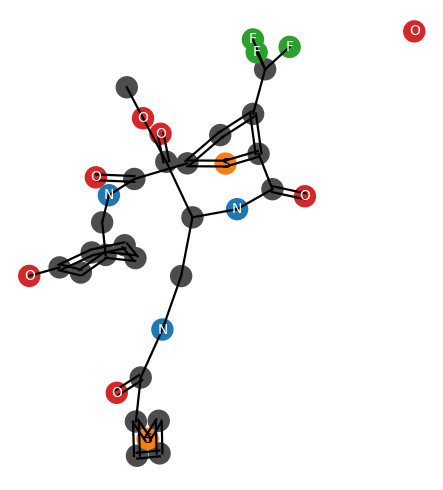

In [6]:
# Inspect one example substrate before rule application
from synkit.IO import smiles_to_graph
from rdkit import Chem
from synedu.Utils.vis import draw_molecular_graph
r = test[2]['r']
G = smiles_to_graph(r)
t = templates[11]['RC']
draw_molecular_graph(G)

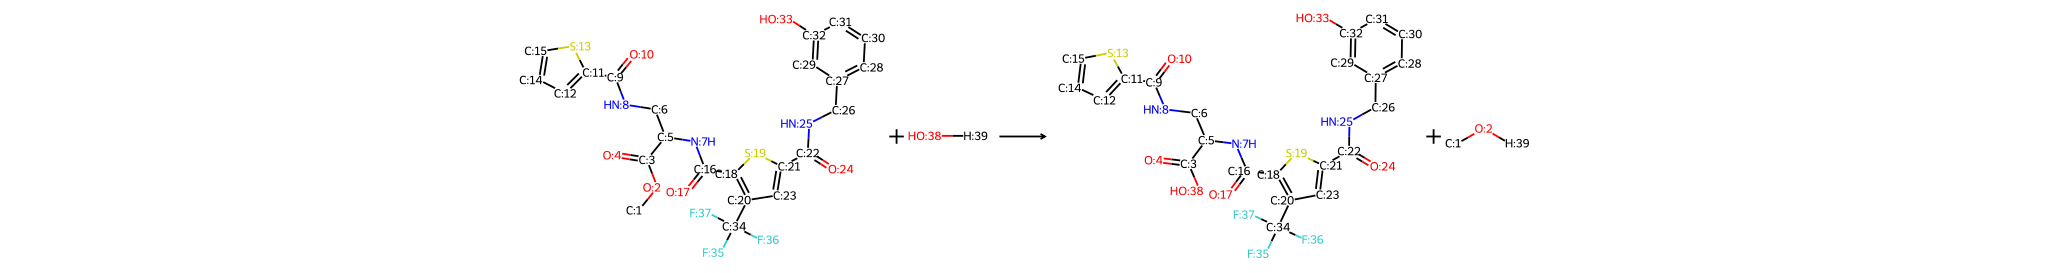

In [7]:
from synedu.Utils.rxn_vis import visualize_reaction
from IPython.display import SVG

ground_truth = test[2]['smart']
svg = visualize_reaction(
    ground_truth,
    svg=True,
    legend="Example",
)

display(SVG(svg))

In [8]:
# Apply one reaction-center template to the example substrate
from synkit.Synthesis.Reactor.syn_reactor import SynReactor

reactor = SynReactor(substrate=r,
                        template=t,
                        explicit_h=True, # Only set True if template has explicit hydrogen; this example contains explicit hydrogen in the template
                        implicit_temp=False, 
                        automorphism=True, 
                        )
reactor.smarts_list

['[CH3:1][O:2][C:3](=[O:4])[CH:5]([CH2:6][NH:7][C:8](=[O:9])[c:10]1[cH:11][cH:12][cH:13][s:14]1)[NH:15][C:16](=[O:17])[c:18]1[s:19][c:20]([C:21](=[O:22])[NH:23][CH2:24][c:25]2[cH:26][cH:27][cH:28][c:29]([O:30][H:39])[cH:31]2)[cH:32][c:33]1[C:34]([F:35])([F:36])[F:37].[OH2:38]>>[CH3:1][O:30][c:29]1[cH:28][cH:27][cH:26][c:25]([CH2:24][NH:23][C:21]([c:20]2[s:19][c:18]([C:16]([NH:15][CH:5]([C:3]([O:2][H:39])=[O:4])[CH2:6][NH:7][C:8](=[O:9])[c:10]3[cH:11][cH:12][cH:13][s:14]3)=[O:17])[c:33]([C:34]([F:35])([F:36])[F:37])[cH:32]2)=[O:22])[cH:31]1.[OH2:38]',
 '[CH3:1][O:2][C:3](=[O:4])[CH:5]([CH2:6][NH:7][C:8](=[O:9])[c:10]1[cH:11][cH:12][cH:13][s:14]1)[NH:15][C:16](=[O:17])[c:18]1[s:19][c:20]([C:21](=[O:22])[NH:23][CH2:24][c:25]2[cH:26][cH:27][cH:28][c:29]([OH:30])[cH:31]2)[cH:32][c:33]1[C:34]([F:35])([F:36])[F:37].[OH:38][H:39]>>[CH3:1][OH:38].[O:2]([C:3](=[O:4])[CH:5]([CH2:6][NH:7][C:8](=[O:9])[c:10]1[cH:11][cH:12][cH:13][s:14]1)[NH:15][C:16](=[O:17])[c:18]1[s:19][c:20]([C:21](=[O:22])[NH:2

In [9]:
# Check whether the ground-truth reaction is recovered among the generated candidates
from synkit.Chem.Reaction.aam_validator import AAMValidator
for value in reactor.smarts_list:
    if AAMValidator().smiles_check(value, ground_truth):
        print(value)

[CH3:1][O:2][C:3](=[O:4])[CH:5]([CH2:6][NH:7][C:8](=[O:9])[c:10]1[cH:11][cH:12][cH:13][s:14]1)[NH:15][C:16](=[O:17])[c:18]1[s:19][c:20]([C:21](=[O:22])[NH:23][CH2:24][c:25]2[cH:26][cH:27][cH:28][c:29]([OH:30])[cH:31]2)[cH:32][c:33]1[C:34]([F:35])([F:36])[F:37].[OH:38][H:39]>>[C:3](=[O:4])([CH:5]([CH2:6][NH:7][C:8](=[O:9])[c:10]1[cH:11][cH:12][cH:13][s:14]1)[NH:15][C:16](=[O:17])[c:18]1[s:19][c:20]([C:21](=[O:22])[NH:23][CH2:24][c:25]2[cH:26][cH:27][cH:28][c:29]([OH:30])[cH:31]2)[cH:32][c:33]1[C:34]([F:35])([F:36])[F:37])[OH:38].[CH3:1][O:2][H:39]


**Q1 — Inspect reaction uniqueness**

The reactions generated by the reactor currently include **atom-to-atom mapping (AAM)**.
At this level, several predictions may appear distinct because their atom indices differ,
even when they encode the **same overall chemical transformation**.

Your task is to:

1. **remove atom mapping** from each generated reaction,
2. **standardize** the resulting reaction representation, and
3. check whether there are still **5 unique reactions**.

If the number of unique reactions decreases, explain **what type of redundancy** has been
collapsed.

---

<details>
<summary><b>Why this question matters</b></summary>

This exercise teaches an important lesson in reaction informatics: **string diversity is
not the same as chemical diversity**. A candidate list can look large simply because the
same transformation is represented with different atom maps or ordering conventions.

</details>

---

<details>
<summary><b>Hint</b></summary>

Use the reaction standardization utility:

```python
from collections import defaultdict
from synkit.Chem.Reaction.standardize import Standardize

std = Standardize()

grouped = defaultdict(list)

for smarts in reactor.smarts_list:
    canonical = std.fit(smarts)
    if canonical is not None:
        grouped[canonical].append(smarts)

grouped = dict(grouped)
grouped
```

Think about whether two mapped reactions can differ only in their **atom correspondence**
while still representing the same transformation after mapping is removed.

</details>

---

<details>
<summary><b>Solution</b></summary>

Removing atom maps and standardizing reduces the set to **4 unique reactions**. The drop
occurs because part of the apparent diversity comes from **mapping-level redundancy**:
two mapped variants differ in atom correspondence, but after removing AAM they collapse
to the **same standardized chemical transformation**.

This is exactly why candidate post-processing is necessary before evaluation: otherwise,
the search space would appear more diverse than it really is.
</details>

In [10]:
# Apply all templates to every entry in the test set
for value in test:
    r = value['r']
    result = []
    for t in templates:
        reactor = SynReactor(substrate=r,
                            template=t['RC'],
                            explicit_h=True, 
                            implicit_temp=False, 
                            automorphism=True, )
        
        sols = reactor.smarts_list
        result.extend(sols)
    value['fw'] = result

**Q2 — Scale up the forward reaction generation**

So far, we have applied templates to **one example substrate**. The next step is to turn
this into a **dataset-level prediction routine**.

Your task is to:

1. write a function that applies **all templates** to a single test entry,
2. collect all generated reaction SMARTS into `value["fw"]`,
3. run this function for the **entire test set**, and
4. speed up the process using **parallel processing**.

Aim for a solution that is clean, reusable, and suitable for larger benchmark runs.

---

<details>
<summary><b>Why this question matters</b></summary>

A one-step predictor is not just a chemistry object; it is also a **search procedure**.
Once the template library grows, throughput and redundancy become practical concerns.
This exercise therefore connects **chemical reasoning** with **computational scaling**.

</details>

---

<details>
<summary><b>Hint</b></summary>

Encapsulate the logic for one entry first. Once the per-entry workflow is stable, use
`joblib.Parallel` or a similar tool to distribute the workload across CPU cores.

</details>

---

<details>
<summary><b>Solution</b></summary>

```python
from copy import deepcopy
from joblib import Parallel, delayed
import logging


def silence_logging() -> None:
    logging.disable(logging.CRITICAL)


def generate_forward_reactions(entry, templates):
    silence_logging()  # apply inside each worker
    value = deepcopy(entry)
    r = value["r"]
    result = []

    for t in templates:
        reactor = SynReactor(
            substrate=r,
            template=t["RC"],
            explicit_h=True,
            implicit_temp=False,
            automorphism=True,
        )
        result.extend(reactor.smarts_list)

    value["fw"] = result
    return value


silence_logging()

test_processed = Parallel(n_jobs=4, verbose=1)(
    delayed(generate_forward_reactions)(entry, templates) for entry in test
)
```

This pattern separates **domain logic** (template application) from **execution logic**
(parallelization), which makes the notebook easier to scale and easier to maintain.
</details>

## 2. Evaluation

Raw rule application usually produces a **large and redundant candidate set**. Two main
sources of redundancy are common:

1. **exact duplicates**, where the same reaction SMARTS is generated more than once, and
2. **mapping variants**, where different atom maps encode the same chemistry.

To interpret model behavior correctly, we therefore evaluate the predictions under **two
equivalence notions**:

- **with atom mapping**: strict, mechanism-aware comparison;
- **without atom mapping**: transformation-level chemical comparison.

These two views answer different scientific questions. The mapped setting asks whether the
system recovers not only the right product, but also a consistent **atom flow**. The
standardized setting asks whether the system recovers the correct **net chemical change**,
even if the exact mapping representation differs.

**Why two evaluation settings?**

Reaction prediction can be judged at different levels of strictness. A model may recover
the right **chemical transformation** even when the **atom mapping** is not identical to
the reference. Conversely, a mapped agreement is stronger evidence that the model has
captured a mechanistically consistent transformation pattern.

Both views are informative, so we keep them separate throughout the analysis.

> **Interpretation guide**
>
> - A hit **without atom mapping** indicates recovery of the correct **reaction outcome**.
> - A hit **with atom mapping** indicates recovery of both the outcome and a compatible
>   **atom correspondence**.
>
> The gap between the two can reveal where the system already knows the chemistry, but
> still struggles with representation-level or mechanism-level precision.

In [11]:
# Inspect one example and evaluate it with and without atom mapping
idx = 0
ground_truth = test[idx]['smart']
fw_list = test[idx]['fw']
len(fw_list) 

590

A first cleanup step is to remove **duplicate predictions** before computing metrics.
This prevents repeated candidates from artificially inflating the denominator in
enrichment calculations.

For one test example, the reactor may generate **hundreds of candidate reactions**.
However, many of them are not genuinely different transformations. Deduplication lets us
separate **search breadth** from **true reaction diversity**.

From an educational standpoint, this is a good reminder that evaluation metrics are only
as meaningful as the representation they operate on. Poor post-processing can make a
predictor look worse—or occasionally better—than it actually is.

### 2.1. With atom map

At the mapped level, we keep the **atom-to-atom correspondence** and canonicalize each
reaction SMARTS before comparison. This gives a **strict equivalence test**:
a prediction is counted as correct only if it matches both the **overall transformation**
and the **underlying atom flow**.

This is the more demanding evaluation setting. It is especially informative when the goal
is to study **reaction mechanism proxies**, **reaction-center fidelity**, or the quality
of the extracted transformation rule itself.

In [12]:
# Canonicalize mapped reaction SMARTS for strict, mechanism-aware comparison
from synkit.Chem.Reaction.canon_rsmi import CanonRSMI
canon = CanonRSMI(wl_iterations=5)
canon_fw = []
for value in fw_list:
    new = canon.canonicalise(value).canonical_rsmi
    canon_fw.append(new)
ground_truth = canon.canonicalise(ground_truth).canonical_rsmi
canon_fw = list(set(canon_fw))
len(canon_fw)

391

In [13]:
def recall(smiles_list, ground_truth):
    hits = sum(s == ground_truth for s in smiles_list)
    return 1 if hits > 0 else 0

# we check if ground truth exist in list of generated smiles

recall(canon_fw, ground_truth)

1

Now we consider the **enrichment problem**.

Suppose the reactor generated many candidate reactions, but only **one** corresponds to
the ground truth. We then ask:

> *How concentrated is the correct answer within the generated candidate set?*

In this notebook, enrichment is computed as

$$
\text{Enrichment} = \frac{\#\text{ ground-truth hits}}{\#\text{ unique generated reactions}}
$$

Because recall is binary here, enrichment can be interpreted as the **fraction of the
candidate space occupied by correct solutions**. Smaller candidate sets with the same
recall therefore yield better enrichment.

In practice, recall and enrichment should be read together:

- **high recall, low enrichment** means the rule library finds the answer but generates a
  broad and weakly focused search space;
- **high recall, higher enrichment** means the correct chemistry is recovered in a more
  selective and efficient candidate set.

In [14]:
def enrichment(smiles_list, ground_truth):
    """
    Compute enrichment given a list of generated SMILES
    and the ground-truth SMILES.

    Parameters
    ----------
    smiles_list : list[str]
        Generated reactions or molecules.
    ground_truth : str
        Ground-truth SMILES.

    Returns
    -------
    float
        Enrichment score.
    """
    hits = sum(s == ground_truth for s in smiles_list)
    return hits / len(smiles_list) if smiles_list else 0.0

enrichment(canon_fw, ground_truth)

0.0025575447570332483

### 2.2. Without atom map

We now move to a less strict but chemically very important evaluation setting. Instead of
requiring the exact mapped reaction, we only ask whether the prediction recovers the
correct **overall transformation**.

To do this, we:

1. **remove atom mapping** from the generated reactions,
2. **standardize** the resulting representations, and
3. compare them against the standardized ground truth.

This collapses mapping-level variants and focuses on **chemical correctness** rather than
full mechanistic identity. For many practical reaction-prediction use cases, this is the
more directly relevant measure because end users often care first about **what product is
formed**, not whether the internal atom labels are identical.

In [15]:
from synkit.Chem.Reaction.standardize import Standardize
std = Standardize()

std_fw = []
for smarts in fw_list:
    canonical = std.fit(smarts)
    if canonical is not None:
        std_fw.append(canonical)

std_fw = list(set(std_fw))
std_gt = std.fit(ground_truth)
len(std_fw)

319

**Q3 — Evaluate the generated reaction set**

After scaling up forward reaction generation, each test entry may contain a **large number
of candidate reactions**. Because different templates can lead to the **same final
transformation**, evaluation must account for redundancy and the level of equivalence used.

Your task is to:

1. compute **recall** and **enrichment**, and
2. compare performance **with atom mapping** versus **without atom mapping**.

---

<details>
<summary><b>Why this question matters</b></summary>

This exercise forces you to interpret performance scientifically rather than just reading a
single score. A predictor can perform differently depending on whether we care about the
**reaction outcome** or the **full mapped transformation**.

</details>

---

<details>
<summary><b>Hint</b></summary>

You can evaluate the same candidate set under two settings:

- **With atom map**: compare mapped reaction SMARTS after canonicalization.
- **Without atom map**: remove mapping, standardize the reactions, then compare the
  standardized transformations.

The first setting tests **mechanistic consistency**; the second tests **chemical
transformation recovery**.

</details>

---

<details>
<summary><b>Solution</b></summary>

```python
print(f"Recall: {recall(std_fw, std_gt)}")
print(f"Enrichment: {enrichment(std_fw, std_gt):.4f}")
```

**Discussion**

Evaluation **without atom mapping** measures **chemical correctness**: it asks whether the
generated reaction matches the correct net transformation, regardless of atom labels.

Evaluation **with atom mapping** is stricter and measures **mechanistic correctness**:
it asks whether the prediction also preserves the correct reactant-to-product atom
correspondence.

After removing atom maps and standardizing the predictions, the number of unique
candidates often decreases. If recall is preserved while enrichment improves, that means
the generator was already proposing the right chemistry, but part of its apparent
diversity came from **representation-level redundancy** rather than distinct solutions.
</details>

## 3. Backward prediction

In **backward prediction**, we reverse the perspective: instead of mapping reactants to
products, we start from the **product side** and enumerate plausible precursor reactions
by applying the same template library in **inverted mode**.

This is closely related to **single-step retrosynthesis**, but it is usually more
ambiguous than forward prediction. A single product can often be disconnected in multiple
valid ways, and the backward direction is strongly influenced by selectivity, leaving
groups, protecting-group strategy, reagent availability, and reaction conditions. As a
result, backward prediction generally exhibits **larger branching** and **lower
specificity** than the forward task.

Educationally, this section is valuable because it shows that the same reaction rule can
support two distinct tasks depending on the direction in which it is applied.

### 3.1. Inspect one backward prediction example

We first invert a single template application to see how the product-side input expands
into candidate precursor reactions.

This example is useful for building retrosynthetic intuition. In the forward direction,
we usually ask, *“What product can this substrate give?”* In the backward direction, we
instead ask, *“What precursor sets could plausibly lead to this product under this local
transformation?”* That inversion greatly enlarges the space of valid answers.

<Axes: >

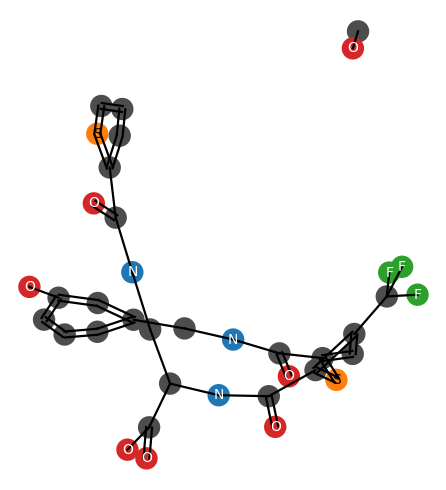

In [16]:
# Reuse the same example in backward mode
p = test[2]['p']
H = smiles_to_graph(p)
t = templates[11]['RC']
gt = test[2]['smart']
draw_molecular_graph(H)

In [17]:
# Apply the same template library in inverted mode for backward prediction
from synkit.Synthesis.Reactor.syn_reactor import SynReactor

reactor = SynReactor(substrate=p,
                        template=t,
                        explicit_h=True, 
                        implicit_temp=False, 
                        automorphism=True, 
                        invert=True, # invert the transformation for backward prediction
                        )
bw = reactor.smarts_list
bw

['[CH3:1][O:2][c:22]1[cH:21][cH:20][cH:19][c:18]([CH2:17][NH:16][C:14]([c:13]2[s:12][c:11]([C:9]([NH:8][CH:7]([CH2:6][NH:5][C:4](=[O:3])[c:34]3[cH:35][cH:36][cH:37][s:38]3)[C:31](=[O:32])[OH:33])=[O:10])[c:26]([C:27]([F:28])([F:29])[F:30])[cH:25]2)=[O:15])[cH:24]1.[OH:23][H:39]>>[CH3:1][O:2][H:39].[O:3]=[C:4]([NH:5][CH2:6][CH:7]([NH:8][C:9](=[O:10])[c:11]1[s:12][c:13]([C:14](=[O:15])[NH:16][CH2:17][c:18]2[cH:19][cH:20][cH:21][c:22]([OH:23])[cH:24]2)[cH:25][c:26]1[C:27]([F:28])([F:29])[F:30])[C:31](=[O:32])[OH:33])[c:34]1[cH:35][cH:36][cH:37][s:38]1',
 '[CH3:1][O:2][C:31]([CH:7]([CH2:6][NH:5][C:4](=[O:3])[c:34]1[cH:35][cH:36][cH:37][s:38]1)[NH:8][C:9](=[O:10])[c:11]1[s:12][c:13]([C:14](=[O:15])[NH:16][CH2:17][c:18]2[cH:19][cH:20][cH:21][c:22]([OH:23])[cH:24]2)[cH:25][c:26]1[C:27]([F:28])([F:29])[F:30])=[O:32].[OH:33][H:39]>>[CH3:1][O:2][H:39].[O:3]=[C:4]([NH:5][CH2:6][CH:7]([NH:8][C:9](=[O:10])[c:11]1[s:12][c:13]([C:14](=[O:15])[NH:16][CH2:17][c:18]2[cH:19][cH:20][cH:21][c:22]([OH:23])[

In [18]:
# Canonicalize mapped backward predictions before comparison
canon = CanonRSMI(wl_iterations=5)
bw_canon = []
for value in bw:
    new = canon.canonicalise(value).canonical_rsmi
    bw_canon.append(new)
gt = canon.canonicalise(gt).canonical_rsmi
recall(bw_canon, gt)

1

### 3.2. Scale backward prediction and summarize performance

As in the forward direction, we next apply the full template library to the dataset,
post-process the generated reactions, and compute macro-level summary metrics.

When interpreting the backward results, it is important to keep expectations realistic.
Lower recall or lower enrichment does not necessarily mean the templates are poor. It may
also reflect the intrinsic fact that **many retrosynthetic disconnections are chemically
reasonable**, even if only one corresponds to the recorded reference reaction.

In [19]:
for value in test:
    p = value['p']
    result = []
    for t in templates:
        reactor = SynReactor(substrate=p,
                            template=t['RC'],
                            explicit_h=True, 
                            implicit_temp=False, 
                            automorphism=True, 
                            invert=True,
                            )
        
        sols = reactor.smarts_list
        result.extend(sols)
    value['bw'] = result

In [21]:
# Helper functions for dataset-level post-processing
canon = CanonRSMI(wl_iterations=5)
def canon_list(list_rsmi):
    canon_lst = []
    for value in list_rsmi:
        new = canon.canonicalise(value).canonical_rsmi
        canon_lst.append(new)
    canon_lst = list(set(canon_lst))
    return canon_lst

std = Standardize()

def std_list(list_rsmi):
    std_lst = []
    for smarts in list_rsmi:
        canonical = std.fit(smarts)
        if canonical is not None:
            std_lst.append(canonical)

    std_lst = list(set(std_lst))
    return std_lst


In [22]:
from copy import deepcopy
from joblib import Parallel, delayed


def process_entry(value):
    value = deepcopy(value)
    value["fw_canon"] = canon_list(value["fw"])
    value["bw_canon"] = canon_list(value["bw"])
    value["gt_canon"] = canon_list([value["smart"]])[0]
    value["fw_std"] = std_list(value["fw"])
    value["bw_std"] = std_list(value["bw"])
    value["gt_std"] = std_list([value["smart"]])[0]
    return value


test = Parallel(n_jobs=4, verbose=2)(
    delayed(process_entry)(value) for value in test
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   25.3s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:  2.2min finished


In [23]:
from copy import deepcopy
from joblib import Parallel, delayed

from synkit.Chem.Reaction.aam_validator import AAMValidator


validator = AAMValidator()


def exact_iso(smiles_list, ground_truth):
    for value in smiles_list:
        if validator.smiles_check(value, ground_truth):
            return 1
    return 0


def recall(smiles_list, ground_truth, use_iso=False):
    if ground_truth in smiles_list:
        return 1
    if use_iso:
        return exact_iso(smiles_list, ground_truth)
    return 0


def enrichment(smiles_list, recall_value):
    if not smiles_list:
        return 0.0
    return recall_value / len(smiles_list)


def evaluate_entry(entry):
    """
    Compute recall and enrichment for one entry.

    Expected keys
    -------------
    fw_canon, bw_canon, gt_canon
    fw_std,   bw_std,   gt_std
    """
    fw_canon_recall = recall(entry["fw_canon"], entry["gt_canon"], use_iso=True)
    bw_canon_recall = recall(entry["bw_canon"], entry["gt_canon"], use_iso=True)
    fw_std_recall = recall(entry["fw_std"], entry["gt_std"], use_iso=False)
    bw_std_recall = recall(entry["bw_std"], entry["gt_std"], use_iso=False)

    return {
        "fw_canon_recall": fw_canon_recall,
        "fw_canon_enrichment": enrichment(entry["fw_canon"], fw_canon_recall),
        "bw_canon_recall": bw_canon_recall,
        "bw_canon_enrichment": enrichment(entry["bw_canon"], bw_canon_recall),
        "fw_std_recall": fw_std_recall,
        "fw_std_enrichment": enrichment(entry["fw_std"], fw_std_recall),
        "bw_std_recall": bw_std_recall,
        "bw_std_enrichment": enrichment(entry["bw_std"], bw_std_recall),
    }


def add_metrics(entry):
    """
    Return a copy of one entry with evaluation metrics added.
    """
    value = deepcopy(entry)
    value.update(evaluate_entry(value))
    return value


def evaluate_entries(entries, n_jobs=4, verbose=2):
    """
    Evaluate all entries in parallel and return the updated list.
    """
    return Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(add_metrics)(entry) for entry in entries
    )


def summarize_metrics(entries):
    """
    Macro-average metrics across all entries.
    """
    n = len(entries)
    if n == 0:
        return {}

    return {
        "fw_canon_recall_mean": sum(x["fw_canon_recall"] for x in entries) / n,
        "fw_canon_enrichment_mean": sum(x["fw_canon_enrichment"] for x in entries) / n,
        "bw_canon_recall_mean": sum(x["bw_canon_recall"] for x in entries) / n,
        "bw_canon_enrichment_mean": sum(x["bw_canon_enrichment"] for x in entries) / n,
        "fw_std_recall_mean": sum(x["fw_std_recall"] for x in entries) / n,
        "fw_std_enrichment_mean": sum(x["fw_std_enrichment"] for x in entries) / n,
        "bw_std_recall_mean": sum(x["bw_std_recall"] for x in entries) / n,
        "bw_std_enrichment_mean": sum(x["bw_std_enrichment"] for x in entries) / n,
    }


# -------------------------
# Usage
# -------------------------

test_eval = evaluate_entries(test, n_jobs=4, verbose=2)
summary = summarize_metrics(test_eval)

print(summary)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 135 tasks      | elapsed:    4.0s


{'fw_canon_recall_mean': 0.96, 'fw_canon_enrichment_mean': 0.02055493843111757, 'bw_canon_recall_mean': 0.885, 'bw_canon_enrichment_mean': 0.023014557791529198, 'fw_std_recall_mean': 0.96, 'fw_std_enrichment_mean': 0.022730427597366976, 'bw_std_recall_mean': 0.9, 'bw_std_enrichment_mean': 0.02458150763850015}


[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    7.1s finished


In [24]:
summary

{'fw_canon_recall_mean': 0.96,
 'fw_canon_enrichment_mean': 0.02055493843111757,
 'bw_canon_recall_mean': 0.885,
 'bw_canon_enrichment_mean': 0.023014557791529198,
 'fw_std_recall_mean': 0.96,
 'fw_std_enrichment_mean': 0.022730427597366976,
 'bw_std_recall_mean': 0.9,
 'bw_std_enrichment_mean': 0.02458150763850015}

Evaluation **without atom mapping** measures **chemical correctness**: it checks whether
the predicted reaction recovers the correct overall transformation, regardless of how atoms
are labeled.

Evaluation **with atom mapping** is stricter and measures **mechanistic correctness**: it
requires not only the right transformation, but also the right **atom correspondence**
between reactants and products.

This distinction is important. A generated reaction may be **chemically correct** while
still failing to reproduce the expected **atom flow**. Therefore, reaction prediction
should be compared at **both levels**:

- the **chemical level**, to assess recovery of the correct transformation, and
- the **mechanistic level**, to assess whether the reaction is represented with a
  consistent underlying atom mapping.

In practice, the standardized setting often performs slightly better than the mapped
setting, especially in backward prediction, because some failures arise from
**mapping-level variation** rather than incorrect chemistry. That gap is informative:
it reveals where the system already captures the right reaction class, but not yet the
right mechanistic representation.

## 4. Discussion

This notebook illustrates a compact but scientifically meaningful **template-based
one-step prediction pipeline**:

1. extract **reaction-center templates** from a mapped training set,
2. apply the templates to unseen substrates or products,
3. deduplicate the generated candidate set, and
4. evaluate predictions at both the **chemical** and **mechanistic** levels.

Several lessons follow from this workflow.

### 4.1. What the pipeline demonstrates

- **Template extraction compresses reaction knowledge.** Rather than replaying full
  training reactions, the system reuses generalized local transformations.
- **Deduplication is essential.** Raw candidate counts can exaggerate diversity and
  distort enrichment if mapping variants are not collapsed.
- **Chemical and mechanistic evaluation answer different questions.** Transformation-level
  recovery tells us whether the chemistry is right; mapped evaluation tells us whether the
  atom flow is also right.
- **Backward prediction is harder.** Reversing a rule library increases ambiguity because
  many precursor sets can map to the same product.

### 4.2. What the pipeline does *not* yet solve

This notebook is intentionally focused on **generation and interpretation**, not on full
reaction-planning performance. In a production system, one would usually also need:

- **template ranking** or candidate scoring,
- **condition awareness**,
- stronger handling of **stereochemistry** and reagent context,
- filtering by **feasibility** or precursor availability, and
- broader benchmarking across reaction classes.

### 4.3. Scientific takeaway

A self-reproduction experiment of this type is best viewed as a **sanity check** for the
graph-rewriting machinery. If performance is weak, the cause may lie in template quality,
mapping inconsistencies, class imbalance, or overly strict matching constraints—not
necessarily in the idea of template-based prediction itself.

For teaching, however, this framework is especially powerful because every step is
interpretable: we can inspect the template, inspect the match, inspect the generated
reaction, and explain why a prediction succeeds or fails.

## 5. Quiz

Answer the following questions using both **chemical intuition** and **graph-based
reasoning**.

---

a. Why can the number of unique predictions decrease after atom mapping is removed?

Explain how two reactions can be distinct at the **mapped** level but identical at the
**standardized chemical** level.

---

b. What is the difference between chemical correctness and mechanistic correctness?

Why is it useful to report **both** evaluation settings instead of only one?

---

c. Why is backward prediction usually more ambiguous than forward prediction?

Discuss the role of **multiple valid disconnections**, selectivity, leaving groups, and
reaction conditions.

---

d. Why does deduplication matter before computing enrichment?

What would go wrong if repeated or mapping-equivalent candidates were counted separately?

---

e. In a template-based system, what does a recovered hit actually demonstrate?

Does it show exact memorization of a training reaction, recovery of a reaction class, or
successful application of a generalized local transformation? Explain.

---

f. Suppose two template libraries have the same recall, but one has clearly better enrichment.

What does this imply about the **focus** of the generated search space? Why can
enrichment be important even when recall is unchanged?

---

g. Why is atom mapping still valuable, even if many downstream users care mainly about the final product?

Relate your answer to **template extraction**, **mechanistic interpretation**, and
diagnosing errors in reaction generation.

## 6. References

1. **Daylight Theory Manual**. *Reaction SMILES and SMARTS*.  
   Foundational reference for reaction string representations and transform logic.

2. **RDKit Documentation**.  
   Practical reference for molecular representations, canonicalization, and reaction
   handling in cheminformatics workflows.

3. Shervashidze, N.; Schweitzer, P.; van Leeuwen, E. J.; Mehlhorn, K.; Borgwardt, K. M.  
   *Weisfeiler–Lehman Graph Kernels*.  
   **Journal of Machine Learning Research** **2011**, *12*, 2539–2561.  
   Relevant background for WL-based hashing and graph comparison.

4. Coley, C. W.; Green, W. H.; Jensen, K. F.  
   *Machine Learning in Computer-Aided Synthesis Planning*.  
   **Accounts of Chemical Research** **2018**, *51* (5), 1281–1289.  
   Broad overview of one-step prediction and retrosynthetic planning.

5. Segler, M. H. S.; Preuss, M.; Waller, M. P.  
   *Planning Chemical Syntheses with Deep Neural Networks and Symbolic AI*.  
   **Nature** **2018**, *555*, 604–610.  
   Widely cited perspective on one-step disconnection logic within synthesis planning.

6. Coley, C. W.; Thomas, D. A.; Lummiss, J. A. M.; Jaworski, J. N.; Breen, C. P.; Schultz,
   V.; Hart, T.; Fishman, J. S.; Rogers, L.; Gao, H.; et al.  
   *A Robotic Platform for Flow Synthesis of Organic Compounds Informed by AI Planning*.  
   **Science** **2019**, *365*, eaax1566.  
   Useful example of how reaction prediction and planning can connect to practical
   synthesis execution.

7. Coley, C. W.; Green, W. H.; Jensen, K. F.  
   *RDChiral: An RDKit Wrapper for Handling Stereochemistry in Retrosynthetic Template
   Extraction and Application*.  
   **Journal of Chemical Information and Modeling** **2019**, *59* (6), 2529–2537.  
   Highly relevant reference for template extraction and application in reaction
   informatics.

8. Schneider, N.; Stiefl, N.; Landrum, G. A.  
   *What’s What: The (Nearly) Definitive Guide to Reaction Role Assignment*.  
   **Journal of Chemical Information and Modeling** **2016**, *56* (12), 2336–2346.  
   Useful background on reaction representation, roles, and practical cheminformatics.